In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!mkdir -p /content/project4
!unzip -q "/content/drive/MyDrive/Project 4 Dataset.zip" -d /content/project4

In [3]:
!pip -q install rasterio torchinfo

import os
import glob
import random
import warnings

import numpy as np
import pandas as pd
import rasterio
from rasterio.errors import NotGeoreferencedWarning
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore", category=NotGeoreferencedWarning)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA A100-SXM4-40GB


In [4]:
DATA_ROOT = "/content/project4/Project 4 Dataset"

TRAIN_IMG_DIR = f"{DATA_ROOT}/raw_labeled_data/images"
TRAIN_MASK_DIR = f"{DATA_ROOT}/raw_labeled_data/annotations"

TEST1_IMG_DIR = f"{DATA_ROOT}/test_data/1/images"
TEST1_MASK_DIR = f"{DATA_ROOT}/test_data/1/annotations"

TEST3_IMG_DIR = f"{DATA_ROOT}/test_data/3/images"
TEST3_MASK_DIR = f"{DATA_ROOT}/test_data/3/annotations"

NUM_CLASSES = 7
CLASS_NAMES = [
    "Background",
    "Seagrass",
    "Coral",
    "Macroalgae",
    "Sand",
    "Land",
    "Ocean"
]

print("Dataset root:", DATA_ROOT)

Dataset root: /content/project4/Project 4 Dataset


In [5]:
!rm -rf "/content/project4/__MACOSX"
!find "/content/project4/Project 4 Dataset" -name ".DS_Store" -delete

In [6]:
!find "/content/project4/Project 4 Dataset" -maxdepth 3 -type d | sort

/content/project4/Project 4 Dataset
/content/project4/Project 4 Dataset/raw_labeled_data
/content/project4/Project 4 Dataset/raw_labeled_data/annotations
/content/project4/Project 4 Dataset/raw_labeled_data/colored
/content/project4/Project 4 Dataset/raw_labeled_data/colored/annotations
/content/project4/Project 4 Dataset/raw_labeled_data/colored/images
/content/project4/Project 4 Dataset/raw_labeled_data/images
/content/project4/Project 4 Dataset/test_data
/content/project4/Project 4 Dataset/test_data/1
/content/project4/Project 4 Dataset/test_data/1/annotations
/content/project4/Project 4 Dataset/test_data/1/colored
/content/project4/Project 4 Dataset/test_data/1/images
/content/project4/Project 4 Dataset/test_data/3
/content/project4/Project 4 Dataset/test_data/3/annotations
/content/project4/Project 4 Dataset/test_data/3/colored
/content/project4/Project 4 Dataset/test_data/3/images


In [7]:
train_imgs = sorted(glob.glob(f"{TRAIN_IMG_DIR}/*.tif"))
train_masks = sorted(glob.glob(f"{TRAIN_MASK_DIR}/*.tif"))

print("Number of training images:", len(train_imgs))
print("Number of training masks:", len(train_masks))

print("\nTraining image files:")
for p in train_imgs:
    print(os.path.basename(p))

print("\nTraining mask files:")
for p in train_masks:
    print(os.path.basename(p))

Number of training images: 9
Number of training masks: 9

Training image files:
WV02052023.tif
WV02202022.tif
WV220101215.tif
WV220130115.tif
WV220140205.tif
WV220171020.tif
WV220230219.tif
WV320141230.tif
WV_01132022.tif

Training mask files:
WV02052023.tif
WV02202022.tif
WV220101215.tif
WV220130115.tif
WV220140205.tif
WV220171020.tif
WV220230219.tif
WV320141230.tif
WV_01132022.tif


In [ ]:
for img_path, mask_path in zip(train_imgs, train_masks):
    with rasterio.open(img_path) as src:
        img = src.read()   # shape: bands, height, width

    with rasterio.open(mask_path) as src:
        mask = src.read(1) # shape: height, width

    print("=" * 80)
    print("Image:", os.path.basename(img_path))
    print("Mask :", os.path.basename(mask_path))
    print("Image shape:", img.shape)
    print("Mask shape :", mask.shape)
    print("Image dtype:", img.dtype, "min:", np.nanmin(img), "max:", np.nanmax(img))
    print("Mask dtype :", mask.dtype, "unique labels:", np.unique(mask))

Image: WV02052023.tif
Mask : WV02052023.tif
Image shape: (8, 794, 2114)
Mask shape : (794, 2114)
Image dtype: uint16 min: 25 max: 2044
Mask dtype : uint8 unique labels: [1 2 3 4 5 6]
Image: WV02202022.tif
Mask : WV02202022.tif
Image shape: (8, 896, 1569)
Mask shape : (896, 1569)
Image dtype: uint16 min: 0 max: 2006
Mask dtype : uint8 unique labels: [0 1 2 3 4 5]
Image: WV220101215.tif
Mask : WV220101215.tif
Image shape: (8, 822, 2138)
Mask shape : (822, 2138)
Image dtype: float32 min: 0.0 max: 2046.3175
Mask dtype : uint8 unique labels: [0 1 2 3 4 5 6]
Image: WV220130115.tif
Mask : WV220130115.tif
Image shape: (8, 822, 2138)
Mask shape : (822, 2138)
Image dtype: uint16 min: 0 max: 2043
Mask dtype : uint8 unique labels: [0 1 2 3 4 5 6]
Image: WV220140205.tif
Mask : WV220140205.tif
Image shape: (8, 822, 2138)
Mask shape : (822, 2138)
Image dtype: uint16 min: 0 max: 2047
Mask dtype : uint8 unique labels: [0 1 2 3 4 5 6]
Image: WV220171020.tif
Mask : WV220171020.tif
Image shape: (8, 822, 2

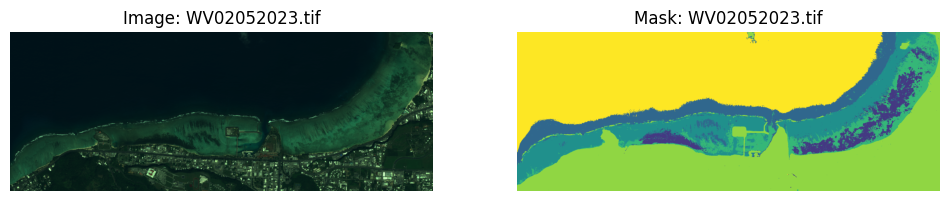

In [ ]:
idx = 0

img_path = train_imgs[idx]
mask_path = train_masks[idx]

with rasterio.open(img_path) as src:
    img = src.read()

with rasterio.open(mask_path) as src:
    mask = src.read(1)

# Use bands 5, 3, 2 approximately as RGB-style visualization if available.
# Since rasterio is 1-indexed but numpy is 0-indexed:
rgb = np.stack([img[4], img[2], img[1]], axis=-1).astype(np.float32)

# Normalize for visualization only
rgb = rgb - np.nanmin(rgb)
rgb = rgb / (np.nanmax(rgb) + 1e-8)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(rgb)
plt.title(f"Image: {os.path.basename(img_path)}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, vmin=0, vmax=6)
plt.title(f"Mask: {os.path.basename(mask_path)}")
plt.axis("off")

plt.show()

In [ ]:
import os, glob
import numpy as np
import rasterio
import pandas as pd

train_imgs = sorted(glob.glob(f"{TRAIN_IMG_DIR}/*.tif"))
train_masks = sorted(glob.glob(f"{TRAIN_MASK_DIR}/*.tif"))

class_counts = np.zeros(NUM_CLASSES, dtype=np.int64)

for mask_path in train_masks:
    with rasterio.open(mask_path) as src:
        mask = src.read(1)

    values, counts = np.unique(mask, return_counts=True)

    for v, c in zip(values, counts):
        if 0 <= v < NUM_CLASSES:
            class_counts[v] += c

total_pixels = class_counts.sum()
class_percent = 100 * class_counts / total_pixels

class_df = pd.DataFrame({
    "Class ID": list(range(NUM_CLASSES)),
    "Class Name": CLASS_NAMES,
    "Pixel Count": class_counts,
    "Percentage (%)": class_percent
})

class_df

,Class ID,Class Name,Pixel Count,Percentage (%)
0,0,Background,608675,3.495928
1,1,Seagrass,532751,3.059858
2,2,Coral,1331689,7.648563
3,3,Macroalgae,2072909,11.905764
4,4,Sand,1496590,8.595673
5,5,Land,6596518,37.887137
6,6,Ocean,4771838,27.407077


In [ ]:
band_sum = np.zeros(8, dtype=np.float64)
band_sq_sum = np.zeros(8, dtype=np.float64)
num_pixels = 0

for img_path in train_imgs:
    with rasterio.open(img_path) as src:
        img = src.read().astype(np.float32)  # shape: 8, H, W

    # Replace NaN/inf if any
    img = np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)

    c, h, w = img.shape
    flat = img.reshape(c, -1)

    band_sum += flat.sum(axis=1)
    band_sq_sum += (flat ** 2).sum(axis=1)
    num_pixels += h * w

band_mean = band_sum / num_pixels
band_std = np.sqrt((band_sq_sum / num_pixels) - (band_mean ** 2))

print("Band mean:")
print(band_mean)

print("\nBand std:")
print(band_std)

Band mean:
[333.43406829 312.73237045 366.93164551 276.62686318 170.52224063
 256.37608106 304.45562999 236.65274939]

Band std:
[106.48109747 127.77042916 205.53932894 204.27003298 144.62084736
 251.54459058 359.86817663 283.61326644]


In [ ]:
from PIL import Image

test1_imgs = sorted(glob.glob(f"{TEST1_IMG_DIR}/*.tif"))
test3_imgs = sorted(glob.glob(f"{TEST3_IMG_DIR}/*.tif"))

test1_masks = sorted(glob.glob(f"{TEST1_MASK_DIR}/*.png"))
test3_masks = sorted(glob.glob(f"{TEST3_MASK_DIR}/*.png"))

print("Agana test images:", len(test1_imgs))
print("Agana test masks :", len(test1_masks))
print("Manell test images:", len(test3_imgs))
print("Manell test masks :", len(test3_masks))

print("\nExample test image shapes:")
for p in test1_imgs[:2] + test3_imgs[:2]:
    with rasterio.open(p) as src:
        img = src.read()
    print(os.path.basename(p), img.shape, img.dtype, img.min(), img.max())

print("\nExample test annotation PNG formats:")
for p in test1_masks[:2] + test3_masks[:2]:
    mask_png = np.array(Image.open(p))
    print(os.path.basename(p), mask_png.shape, mask_png.dtype, "unique sample:", np.unique(mask_png.reshape(-1, mask_png.shape[-1]) if mask_png.ndim == 3 else mask_png)[:10])

Agana test images: 15
Agana test masks : 15
Manell test images: 6
Manell test masks : 6

Example test image shapes:
WV10212021_aganaClip.tif (8, 822, 2138) uint16 0 2018
WV3_01112021_aganaclip.tif (8, 822, 2138) uint16 0 2017
WV3_01132022_MGclip.tif (8, 1370, 2050) uint16 0 2034
WV3_02202022_MGclip.tif (8, 1370, 2050) uint16 0 2037

Example test annotation PNG formats:
WV10212021_aganaClip.png (822, 2138, 3) uint8 unique sample: [  0  42  76  80  98 101 117 127 134 138]
WV3_01112021_aganaclip.png (822, 2138, 3) uint8 unique sample: [  0  42  76  80  98 101 117 127 134 138]
WV3_01132022_MGclip.png (1370, 2050, 3) uint8 unique sample: [  0  42  76  80  98 101 117 127 134 138]
WV3_02202022_MGclip.png (1370, 2050, 3) uint8 unique sample: [  0  42  76  80  98 101 117 127 134 138]


In [ ]:
# Class weights for weighted CrossEntropyLoss
# Higher weight = rarer class gets more importance during training

class_counts_np = class_counts.astype(np.float32)

class_weights = total_pixels / (NUM_CLASSES * class_counts_np)
class_weights = class_weights / class_weights.mean()

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

weights_df = pd.DataFrame({
    "Class ID": list(range(NUM_CLASSES)),
    "Class Name": CLASS_NAMES,
    "Pixel Count": class_counts,
    "Percentage (%)": class_percent,
    "Loss Weight": class_weights
})

weights_df

,Class ID,Class Name,Pixel Count,Percentage (%),Loss Weight
0,0,Background,608675,3.495928,1.988776
1,1,Seagrass,532751,3.059858,2.272203
2,2,Coral,1331689,7.648563,0.909010
3,3,Macroalgae,2072909,11.905764,0.583971
4,4,Sand,1496590,8.595673,0.808851
5,5,Land,6596518,37.887137,0.183509
6,6,Ocean,4771838,27.407077,0.253680


In [ ]:
COLOR_TRAIN_MASK_DIR = f"{DATA_ROOT}/raw_labeled_data/colored/annotations"

color_sum = np.zeros((NUM_CLASSES, 3), dtype=np.float64)
color_count = np.zeros(NUM_CLASSES, dtype=np.int64)

for mask_path in train_masks:
    name = os.path.basename(mask_path)
    color_path = os.path.join(COLOR_TRAIN_MASK_DIR, name.replace(".tif", ".png"))

    with rasterio.open(mask_path) as src:
        label_mask = src.read(1)

    color_mask = np.array(Image.open(color_path).convert("RGB"))

    assert label_mask.shape == color_mask.shape[:2], f"Shape mismatch for {name}"

    for cls in range(NUM_CLASSES):
        pixels = color_mask[label_mask == cls]
        if len(pixels) > 0:
            color_sum[cls] += pixels.reshape(-1, 3).sum(axis=0)
            color_count[cls] += pixels.shape[0]

class_colors = np.round(color_sum / color_count[:, None]).astype(np.uint8)

color_df = pd.DataFrame({
    "Class ID": list(range(NUM_CLASSES)),
    "Class Name": CLASS_NAMES,
    "R": class_colors[:, 0],
    "G": class_colors[:, 1],
    "B": class_colors[:, 2],
})

color_df

,Class ID,Class Name,R,G,B
0,0,Background,0,0,0
1,1,Seagrass,134,164,117
2,2,Coral,255,127,80
3,3,Macroalgae,101,138,42
4,4,Sand,203,189,147
5,5,Land,139,98,76
6,6,Ocean,127,205,255


In [ ]:
def rgb_png_to_class_mask(rgb_mask, class_colors):
    """
    Convert RGB colored annotation PNG to class-ID mask.
    Uses exact RGB matching first.
    If unexpected colors exist, falls back to nearest color using int32 to avoid overflow.
    """
    rgb_mask = rgb_mask.astype(np.uint8)
    h, w, _ = rgb_mask.shape

    class_mask = np.zeros((h, w), dtype=np.uint8)

    # Exact color matching
    matched = np.zeros((h, w), dtype=bool)

    for cls_id, color in enumerate(class_colors):
        match = np.all(rgb_mask == color.reshape(1, 1, 3), axis=-1)
        class_mask[match] = cls_id
        matched |= match

    # Fallback nearest-color conversion only for unmatched pixels
    if not np.all(matched):
        rgb = rgb_mask.astype(np.int32)
        colors = class_colors.astype(np.int32)

        distances = ((rgb[:, :, None, :] - colors[None, None, :, :]) ** 2).sum(axis=-1)
        nearest = np.argmin(distances, axis=-1).astype(np.uint8)

        class_mask[~matched] = nearest[~matched]

    return class_mask

In [ ]:
for p in test1_masks[:1] + test3_masks[:1]:
    rgb_mask = np.array(Image.open(p).convert("RGB"))
    class_mask = rgb_png_to_class_mask(rgb_mask, class_colors)

    print(os.path.basename(p))
    print("RGB shape:", rgb_mask.shape)
    print("Converted class mask shape:", class_mask.shape)
    print("Unique labels:", np.unique(class_mask))
    print()

WV10212021_aganaClip.png
RGB shape: (822, 2138, 3)
Converted class mask shape: (822, 2138)
Unique labels: [0 1 2 3 4 5 6]

WV3_01132022_MGclip.png
RGB shape: (1370, 2050, 3)
Converted class mask shape: (1370, 2050)
Unique labels: [0 1 2 3 4 5 6]



In [ ]:
all_names = [os.path.basename(p) for p in train_imgs]

# One smaller Agana-style image and one larger Manell-style image for validation
val_names = ["WV_01132022.tif", "WV320141230.tif"]

train_names = [n for n in all_names if n not in val_names]

print("Training files:")
for n in train_names:
    print(" ", n)

print("\nValidation files:")
for n in val_names:
    print(" ", n)

Training files:
  WV02052023.tif
  WV02202022.tif
  WV220101215.tif
  WV220130115.tif
  WV220140205.tif
  WV220171020.tif
  WV220230219.tif

Validation files:
  WV_01132022.tif
  WV320141230.tif


In [ ]:
import random

BAND_MEAN = np.array([
    333.43406829, 312.73237045, 366.93164551, 276.62686318,
    170.52224063, 256.37608106, 304.45562999, 236.65274939
], dtype=np.float32)

BAND_STD = np.array([
    106.48109747, 127.77042916, 205.53932894, 204.27003298,
    144.62084736, 251.54459058, 359.86817663, 283.61326644
], dtype=np.float32)


class BenthicPatchDataset(Dataset):
    def __init__(
        self,
        names,
        img_dir,
        mask_dir,
        patch_size=256,
        patches_per_image=300,
        augment=True,
        balanced=True
    ):
        self.names = names
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.patch_size = patch_size
        self.patches_per_image = patches_per_image
        self.augment = augment
        self.balanced = balanced

        self.images = []
        self.masks = []
        self.rare_class_coords = []

        rare_classes = [1, 2, 3, 4]  # seagrass, coral, macroalgae, sand

        for name in self.names:
            img_path = os.path.join(self.img_dir, name)
            mask_path = os.path.join(self.mask_dir, name)

            with rasterio.open(img_path) as src:
                img = src.read().astype(np.float32)

            with rasterio.open(mask_path) as src:
                mask = src.read(1).astype(np.int64)

            img = np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)

            # 8-band normalization
            img = (img - BAND_MEAN[:, None, None]) / (BAND_STD[:, None, None] + 1e-8)

            self.images.append(img)
            self.masks.append(mask)

            coords = {}
            for cls in rare_classes:
                ys, xs = np.where(mask == cls)
                coords[cls] = (ys, xs)
            self.rare_class_coords.append(coords)

    def __len__(self):
        return len(self.names) * self.patches_per_image

    def _random_crop(self, h, w):
        ps = self.patch_size
        y0 = random.randint(0, h - ps)
        x0 = random.randint(0, w - ps)
        return y0, x0

    def _centered_crop(self, h, w, cy, cx):
        ps = self.patch_size
        y0 = int(np.clip(cy - ps // 2, 0, h - ps))
        x0 = int(np.clip(cx - ps // 2, 0, w - ps))
        return y0, x0

    def __getitem__(self, idx):
        img_idx = idx % len(self.images)

        img = self.images[img_idx]
        mask = self.masks[img_idx]

        _, h, w = img.shape
        ps = self.patch_size

        # Balanced patch sampling:
        # 70% of the time, crop around rare habitat classes.
        if self.balanced and random.random() < 0.7:
            coords = self.rare_class_coords[img_idx]
            available_classes = [c for c, (ys, xs) in coords.items() if len(ys) > 0]

            if len(available_classes) > 0:
                target_cls = random.choice(available_classes)
                ys, xs = coords[target_cls]
                pos = random.randint(0, len(ys) - 1)
                y0, x0 = self._centered_crop(h, w, ys[pos], xs[pos])
            else:
                y0, x0 = self._random_crop(h, w)
        else:
            y0, x0 = self._random_crop(h, w)

        img_patch = img[:, y0:y0 + ps, x0:x0 + ps]
        mask_patch = mask[y0:y0 + ps, x0:x0 + ps]

        # Spatial augmentations only
        if self.augment:
            if random.random() < 0.5:
                img_patch = np.flip(img_patch, axis=2)
                mask_patch = np.flip(mask_patch, axis=1)

            if random.random() < 0.5:
                img_patch = np.flip(img_patch, axis=1)
                mask_patch = np.flip(mask_patch, axis=0)

        img_patch = img_patch.copy()
        mask_patch = mask_patch.copy()

        return torch.tensor(img_patch, dtype=torch.float32), torch.tensor(mask_patch, dtype=torch.long)

In [ ]:
PATCH_SIZE = 256
BATCH_SIZE = 16

train_dataset = BenthicPatchDataset(
    train_names,
    TRAIN_IMG_DIR,
    TRAIN_MASK_DIR,
    patch_size=PATCH_SIZE,
    patches_per_image=300,
    augment=True,
    balanced=True
)

val_dataset = BenthicPatchDataset(
    val_names,
    TRAIN_IMG_DIR,
    TRAIN_MASK_DIR,
    patch_size=PATCH_SIZE,
    patches_per_image=80,
    augment=False,
    balanced=False
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

xb, yb = next(iter(train_loader))

print("Input batch shape:", xb.shape)
print("Mask batch shape :", yb.shape)
print("Input dtype:", xb.dtype)
print("Mask dtype :", yb.dtype)
print("Unique mask labels in batch:", torch.unique(yb))

Input batch shape: torch.Size([16, 8, 256, 256])
Mask batch shape : torch.Size([16, 256, 256])
Input dtype: torch.float32
Mask dtype : torch.int64
Unique mask labels in batch: tensor([0, 1, 2, 3, 4, 5, 6])


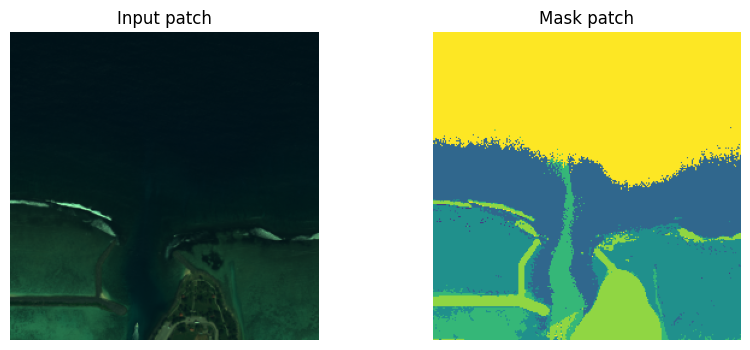

In [ ]:
def show_training_patch(x, y, idx=0):
    x_np = x[idx].cpu().numpy()
    y_np = y[idx].cpu().numpy()

    # De-normalize selected bands for visualization only
    img_denorm = x_np * BAND_STD[:, None, None] + BAND_MEAN[:, None, None]

    # Approximate RGB visualization using Red, Green, Blue bands
    rgb = np.stack([img_denorm[4], img_denorm[2], img_denorm[1]], axis=-1)
    rgb = rgb.astype(np.float32)
    rgb = rgb - rgb.min()
    rgb = rgb / (rgb.max() + 1e-8)

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(rgb)
    plt.title("Input patch")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(y_np, vmin=0, vmax=6)
    plt.title("Mask patch")
    plt.axis("off")

    plt.show()

show_training_patch(xb, yb, idx=0)

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Dropout2d(dropout)
        )

    def forward(self, x):
        return self.block(x)


class UNetSmall(nn.Module):
    def __init__(self, in_channels=8, num_classes=7, base_channels=32):
        super().__init__()

        self.enc1 = DoubleConv(in_channels, base_channels)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(base_channels, base_channels * 2)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(base_channels * 2, base_channels * 4)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(base_channels * 4, base_channels * 8)

        self.up3 = nn.ConvTranspose2d(base_channels * 8, base_channels * 4, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(base_channels * 8, base_channels * 4)

        self.up2 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(base_channels * 4, base_channels * 2)

        self.up1 = nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(base_channels * 2, base_channels)

        self.out_conv = nn.Conv2d(base_channels, num_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)

        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))

        b = self.bottleneck(self.pool3(e3))

        d3 = self.up3(b)
        if d3.shape[-2:] != e3.shape[-2:]:
            d3 = F.interpolate(d3, size=e3.shape[-2:], mode="bilinear", align_corners=False)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        if d2.shape[-2:] != e2.shape[-2:]:
            d2 = F.interpolate(d2, size=e2.shape[-2:], mode="bilinear", align_corners=False)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        if d1.shape[-2:] != e1.shape[-2:]:
            d1 = F.interpolate(d1, size=e1.shape[-2:], mode="bilinear", align_corners=False)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out_conv(d1)




model = UNetSmall(in_channels=8, num_classes=NUM_CLASSES, base_channels=32).to(device)

xb, yb = next(iter(train_loader))
xb = xb.to(device)

with torch.no_grad():
    out = model(xb)

print("Input shape :", xb.shape)
print("Output shape:", out.shape)
print("Target shape:", yb.shape)

Input shape : torch.Size([16, 8, 256, 256])
Output shape: torch.Size([16, 7, 256, 256])
Target shape: torch.Size([16, 256, 256])


In [ ]:
def dice_loss_multiclass(logits, targets, num_classes=7, eps=1e-6):
    probs = torch.softmax(logits, dim=1)

    targets_onehot = F.one_hot(targets, num_classes=num_classes)
    targets_onehot = targets_onehot.permute(0, 3, 1, 2).float()

    dims = (0, 2, 3)
    intersection = torch.sum(probs * targets_onehot, dims)
    cardinality = torch.sum(probs + targets_onehot, dims)

    dice = (2.0 * intersection + eps) / (cardinality + eps)
    return 1.0 - dice.mean()


ce_loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor)

def combined_loss(logits, targets):
    ce = ce_loss_fn(logits, targets)
    dice = dice_loss_multiclass(logits, targets, num_classes=NUM_CLASSES)
    return 0.7 * ce + 0.3 * dice


def compute_confusion_matrix(preds, targets, num_classes=7):
    preds = preds.reshape(-1)
    targets = targets.reshape(-1)

    if torch.is_tensor(preds):
        preds = preds.detach().cpu().numpy()
    if torch.is_tensor(targets):
        targets = targets.detach().cpu().numpy()

    mask = (targets >= 0) & (targets < num_classes)

    hist = np.bincount(
        num_classes * targets[mask].astype(int) + preds[mask].astype(int),
        minlength=num_classes ** 2
    ).reshape(num_classes, num_classes)

    return hist


def metrics_from_confusion(hist):
    correct = np.diag(hist).sum()
    total = hist.sum()
    pixel_acc = correct / (total + 1e-8)

    intersection = np.diag(hist)
    union = hist.sum(axis=1) + hist.sum(axis=0) - intersection

    iou = np.full(NUM_CLASSES, np.nan, dtype=np.float64)
    valid = union > 0
    iou[valid] = intersection[valid] / union[valid]

    miou = np.nanmean(iou)

    return pixel_acc, miou, iou

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

EPOCHS = 25

history = {
    "train_loss": [],
    "val_loss": [],
    "val_pixel_acc": [],
    "val_miou": []
}

best_val_miou = -1.0
best_model_path = "/content/best_benthic_unet.pth"


def train_one_epoch(model, loader):
    model.train()

    running_loss = 0.0
    total_batches = 0

    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        logits = model(images)
        loss = combined_loss(logits, masks)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        running_loss += loss.item()
        total_batches += 1

    return running_loss / total_batches


def evaluate(model, loader):
    model.eval()

    running_loss = 0.0
    total_batches = 0
    hist_total = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)
            loss = combined_loss(logits, masks)

            preds = torch.argmax(logits, dim=1)

            hist_total += compute_confusion_matrix(preds, masks, NUM_CLASSES)

            running_loss += loss.item()
            total_batches += 1

    pixel_acc, miou, per_class_iou = metrics_from_confusion(hist_total)

    return running_loss / total_batches, pixel_acc, miou, per_class_iou


for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader)
    val_loss, val_pixel_acc, val_miou, per_class_iou = evaluate(model, val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_pixel_acc"].append(val_pixel_acc)
    history["val_miou"].append(val_miou)

    print(f"Epoch [{epoch+1}/{EPOCHS}]")
    print(f"  Train Loss : {train_loss:.4f}")
    print(f"  Val Loss   : {val_loss:.4f}")
    print(f"  Val Acc    : {val_pixel_acc*100:.2f}%")
    print(f"  Val mIoU   : {val_miou*100:.2f}%")

    print("  Per-class IoU:")
    for cls_id, cls_name in enumerate(CLASS_NAMES):
        print(f"    {cls_id} {cls_name:12s}: {per_class_iou[cls_id]*100:.2f}%")

    if val_miou > best_val_miou:
        best_val_miou = val_miou
        torch.save(model.state_dict(), best_model_path)
        print("  Saved new best model.")

    print("-" * 60)

Epoch [1/25]
  Train Loss : 0.9232
  Val Loss   : 0.7448
  Val Acc    : 80.67%
  Val mIoU   : 60.83%
  Per-class IoU:
    0 Background  : 96.13%
    1 Seagrass    : 24.99%
    2 Coral       : 40.28%
    3 Macroalgae  : 46.86%
    4 Sand        : 36.51%
    5 Land        : 96.91%
    6 Ocean       : 84.11%
  Saved new best model.
------------------------------------------------------------
Epoch [2/25]
  Train Loss : 0.6534
  Val Loss   : 0.8096
  Val Acc    : 78.61%
  Val mIoU   : 59.78%
  Per-class IoU:
    0 Background  : 96.20%
    1 Seagrass    : 34.02%
    2 Coral       : 31.70%
    3 Macroalgae  : 44.02%
    4 Sand        : 25.52%
    5 Land        : 97.52%
    6 Ocean       : 89.50%
------------------------------------------------------------
Epoch [3/25]
  Train Loss : 0.5665
  Val Loss   : 0.6774
  Val Acc    : 80.77%
  Val mIoU   : 64.70%
  Per-class IoU:
    0 Background  : 96.09%
    1 Seagrass    : 32.55%
    2 Coral       : 42.00%
    3 Macroalgae  : 50.93%
    4 Sand    

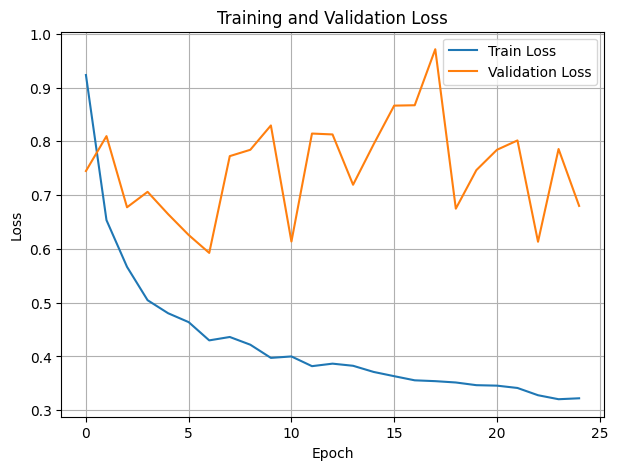

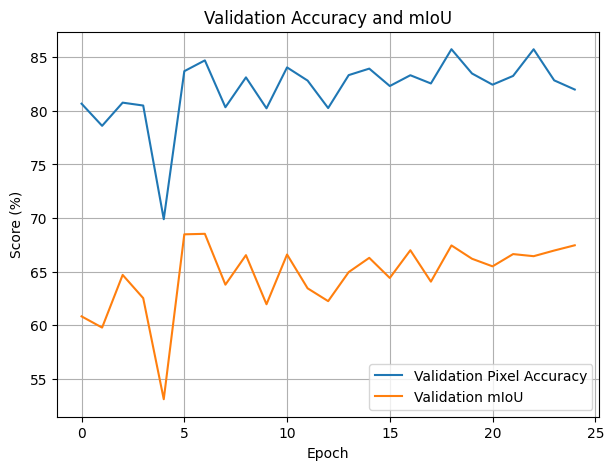

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(np.array(history["val_pixel_acc"]) * 100, label="Validation Pixel Accuracy")
plt.plot(np.array(history["val_miou"]) * 100, label="Validation mIoU")
plt.xlabel("Epoch")
plt.ylabel("Score (%)")
plt.title("Validation Accuracy and mIoU")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
!cp /content/best_benthic_unet.pth "/content/drive/MyDrive/best_benthic_unet.pth"
print("Best model saved to Google Drive.")

Best model saved to Google Drive.


In [ ]:
model = UNetSmall(in_channels=8, num_classes=NUM_CLASSES, base_channels=32).to(device)
model.load_state_dict(torch.load("/content/best_benthic_unet.pth", map_location=device))
model.eval()

print("Loaded best validation-mIoU checkpoint.")

Loaded best validation-mIoU checkpoint.


In [ ]:
OUT_DIR = "/content/benthic_results"
MASK_OUT_DIR = f"{OUT_DIR}/predicted_masks"
COLOR_OUT_DIR = f"{OUT_DIR}/colored_predictions"
ERROR_OUT_DIR = f"{OUT_DIR}/error_visualizations"

os.makedirs(MASK_OUT_DIR, exist_ok=True)
os.makedirs(COLOR_OUT_DIR, exist_ok=True)
os.makedirs(ERROR_OUT_DIR, exist_ok=True)


def class_mask_to_rgb(mask, class_colors):
    return class_colors[mask]


def read_and_normalize_tif(img_path):
    with rasterio.open(img_path) as src:
        img = src.read().astype(np.float32)

    img = np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)
    img = (img - BAND_MEAN[:, None, None]) / (BAND_STD[:, None, None] + 1e-8)

    return img


def sliding_window_predict(model, img, patch_size=256, stride=128, batch_size=16):
    model.eval()

    c, h, w = img.shape
    ps = patch_size

    pad_h = max(0, ps - h)
    pad_w = max(0, ps - w)

    if pad_h > 0 or pad_w > 0:
        img = np.pad(
            img,
            ((0, 0), (0, pad_h), (0, pad_w)),
            mode="reflect"
        )

    _, hp, wp = img.shape

    y_positions = list(range(0, hp - ps + 1, stride))
    x_positions = list(range(0, wp - ps + 1, stride))

    if y_positions[-1] != hp - ps:
        y_positions.append(hp - ps)
    if x_positions[-1] != wp - ps:
        x_positions.append(wp - ps)

    prob_sum = torch.zeros((NUM_CLASSES, hp, wp), dtype=torch.float32, device=device)
    count_sum = torch.zeros((1, hp, wp), dtype=torch.float32, device=device)

    patches = []
    coords = []

    with torch.no_grad():
        for y0 in y_positions:
            for x0 in x_positions:
                patch = img[:, y0:y0 + ps, x0:x0 + ps]
                patches.append(patch)
                coords.append((y0, x0))

                if len(patches) == batch_size:
                    batch = torch.tensor(np.stack(patches), dtype=torch.float32).to(device)
                    logits = model(batch)
                    probs = torch.softmax(logits, dim=1)

                    for i, (yy, xx) in enumerate(coords):
                        prob_sum[:, yy:yy + ps, xx:xx + ps] += probs[i]
                        count_sum[:, yy:yy + ps, xx:xx + ps] += 1.0

                    patches = []
                    coords = []

        if len(patches) > 0:
            batch = torch.tensor(np.stack(patches), dtype=torch.float32).to(device)
            logits = model(batch)
            probs = torch.softmax(logits, dim=1)

            for i, (yy, xx) in enumerate(coords):
                prob_sum[:, yy:yy + ps, xx:xx + ps] += probs[i]
                count_sum[:, yy:yy + ps, xx:xx + ps] += 1.0

    avg_probs = prob_sum / count_sum
    pred = torch.argmax(avg_probs, dim=0).detach().cpu().numpy().astype(np.uint8)

    return pred[:h, :w]


def make_error_visualization(pred_mask, gt_mask):
    pred_rgb = class_mask_to_rgb(pred_mask, class_colors).astype(np.uint8)
    error_rgb = pred_rgb.copy()

    wrong = pred_mask != gt_mask
    error_rgb[wrong] = np.array([255, 0, 0], dtype=np.uint8)

    return error_rgb


def evaluate_single_prediction(pred_mask, gt_mask):
    hist = compute_confusion_matrix(pred_mask, gt_mask, NUM_CLASSES)
    pixel_acc, miou, per_class_iou = metrics_from_confusion(hist)
    return pixel_acc, miou, per_class_iou

In [ ]:
def run_test_folder(region_name, img_dir, mask_dir):
    img_paths = sorted(glob.glob(f"{img_dir}/*.tif"))

    region_rows = []

    for img_path in img_paths:
        base = os.path.splitext(os.path.basename(img_path))[0]
        gt_path = os.path.join(mask_dir, base + ".png")

        print(f"Processing {region_name}: {base}")

        img = read_and_normalize_tif(img_path)
        pred_mask = sliding_window_predict(
            model,
            img,
            patch_size=256,
            stride=128,
            batch_size=16
        )

        # Save class-ID prediction mask
        pred_id_path = os.path.join(MASK_OUT_DIR, f"{region_name}_{base}_pred_ids.png")
        Image.fromarray(pred_mask).save(pred_id_path)

        # Save colored prediction mask
        pred_rgb = class_mask_to_rgb(pred_mask, class_colors).astype(np.uint8)
        pred_color_path = os.path.join(COLOR_OUT_DIR, f"{region_name}_{base}_pred_color.png")
        Image.fromarray(pred_rgb).save(pred_color_path)

        # Evaluate if GT annotation exists
        if os.path.exists(gt_path):
            gt_rgb = np.array(Image.open(gt_path).convert("RGB"))
            gt_mask = rgb_png_to_class_mask(gt_rgb, class_colors)

            pixel_acc, miou, per_class_iou = evaluate_single_prediction(pred_mask, gt_mask)

            error_rgb = make_error_visualization(pred_mask, gt_mask)
            error_path = os.path.join(ERROR_OUT_DIR, f"{region_name}_{base}_error.png")
            Image.fromarray(error_rgb).save(error_path)

            row = {
                "Region": region_name,
                "Image": base,
                "Pixel Accuracy": pixel_acc,
                "mIoU": miou
            }

            for cls_id, cls_name in enumerate(CLASS_NAMES):
                row[f"IoU_{cls_id}_{cls_name}"] = per_class_iou[cls_id]

            region_rows.append(row)

        else:
            print(f"  Warning: ground truth not found for {base}")

    return region_rows


test_rows = []

test_rows += run_test_folder("Agana", TEST1_IMG_DIR, TEST1_MASK_DIR)
test_rows += run_test_folder("ManellGeus", TEST3_IMG_DIR, TEST3_MASK_DIR)

test_results_df = pd.DataFrame(test_rows)
test_results_df

Processing Agana: WV10212021_aganaClip
Processing Agana: WV3_01112021_aganaclip
Processing Agana: WV3_01182021_aganaClip
Processing Agana: WV3_07302023_AganaClip
Processing Agana: WV_01132022_AganaClip
Processing Agana: WV_01152013_AganaClip
Processing Agana: WV_02052014_aganaclip
Processing Agana: WV_02052023_AganaClip
Processing Agana: WV_02292020_AganaClip
Processing Agana: WV_03082022_composite_aganaclip
Processing Agana: WV_05122018_aganaclip
Processing Agana: WV_07272015_AganaClip
Processing Agana: WV_10202017_aganaClip
Processing Agana: WV_11102016_Aganaclip
Processing Agana: WV_12152010_AganaClip
Processing ManellGeus: WV3_01132022_MGclip
Processing ManellGeus: WV3_02202022_MGclip
Processing ManellGeus: WV3_12302014_MGclip
Processing ManellGeus: WV3_20220113_Composite_8bands_Manell_AOI_XSM_updated
Processing ManellGeus: WV_MG_01052024_composite_clip
Processing ManellGeus: WV_MG_02142024_composite_clip


,Region,Image,Pixel Accuracy,mIoU,IoU_0_Background,IoU_1_Seagrass,IoU_2_Coral,IoU_3_Macroalgae,IoU_4_Sand,IoU_5_Land,IoU_6_Ocean
0,Agana,WV10212021_aganaClip,0.931898,0.735790,0.946705,0.337581,0.648118,0.795820,0.509057,0.965303,0.947944
1,Agana,WV3_01112021_aganaclip,0.407035,0.338078,0.927481,0.122417,0.000297,0.277527,0.082042,0.956782,0.000000
2,Agana,WV3_01182021_aganaClip,0.355405,0.279335,0.841124,0.023443,0.000000,0.067621,0.135437,0.887717,0.000000
3,Agana,WV3_07302023_AganaClip,0.857763,0.612933,0.849042,0.201446,0.646058,0.447428,0.268933,0.948260,0.929365
4,Agana,WV_01132022_AganaClip,0.949592,0.798246,0.946681,0.460365,0.773375,0.812630,0.634892,0.985097,0.974680
5,Agana,WV_01152013_AganaClip,0.933475,0.778721,0.928931,0.503234,0.622142,0.744188,0.715495,0.985958,0.951097
6,Agana,WV_02052014_aganaclip,0.941680,0.815217,0.953435,0.568476,0.670081,0.764440,0.822246,0.988910,0.938932
7,Agana,WV_02052023_AganaClip,0.950763,0.825563,0.946390,0.546139,0.802788,0.804169,0.718768,0.991934,0.968752
8,Agana,WV_02292020_AganaClip,0.947220,0.819128,0.948734,0.543191,0.729594,0.786596,0.778004,0.990998,0.956777
9,Agana,WV_03082022_composite_aganaclip,0.870914,0.658962,0.884191,0.237266,0.638710,0.323724,0.592906,0.986249,0.949688


In [ ]:
metrics_csv_path = f"{OUT_DIR}/test_metrics.csv"
test_results_df.to_csv(metrics_csv_path, index=False)

print("Saved:", metrics_csv_path)

print("Overall test results:")
print("Mean Pixel Accuracy:", test_results_df["Pixel Accuracy"].mean() * 100)
print("Mean mIoU:", test_results_df["mIoU"].mean() * 100)

print("\nBy region:")
display(test_results_df.groupby("Region")[["Pixel Accuracy", "mIoU"]].mean() * 100)

Saved: /content/benthic_results/test_metrics.csv
Overall test results:
Mean Pixel Accuracy: 79.32729955215937
Mean mIoU: 63.50052350925965

By region:


,Pixel Accuracy,mIoU
Region,,
Agana,77.687373,64.556839
ManellGeus,83.427115,60.859734


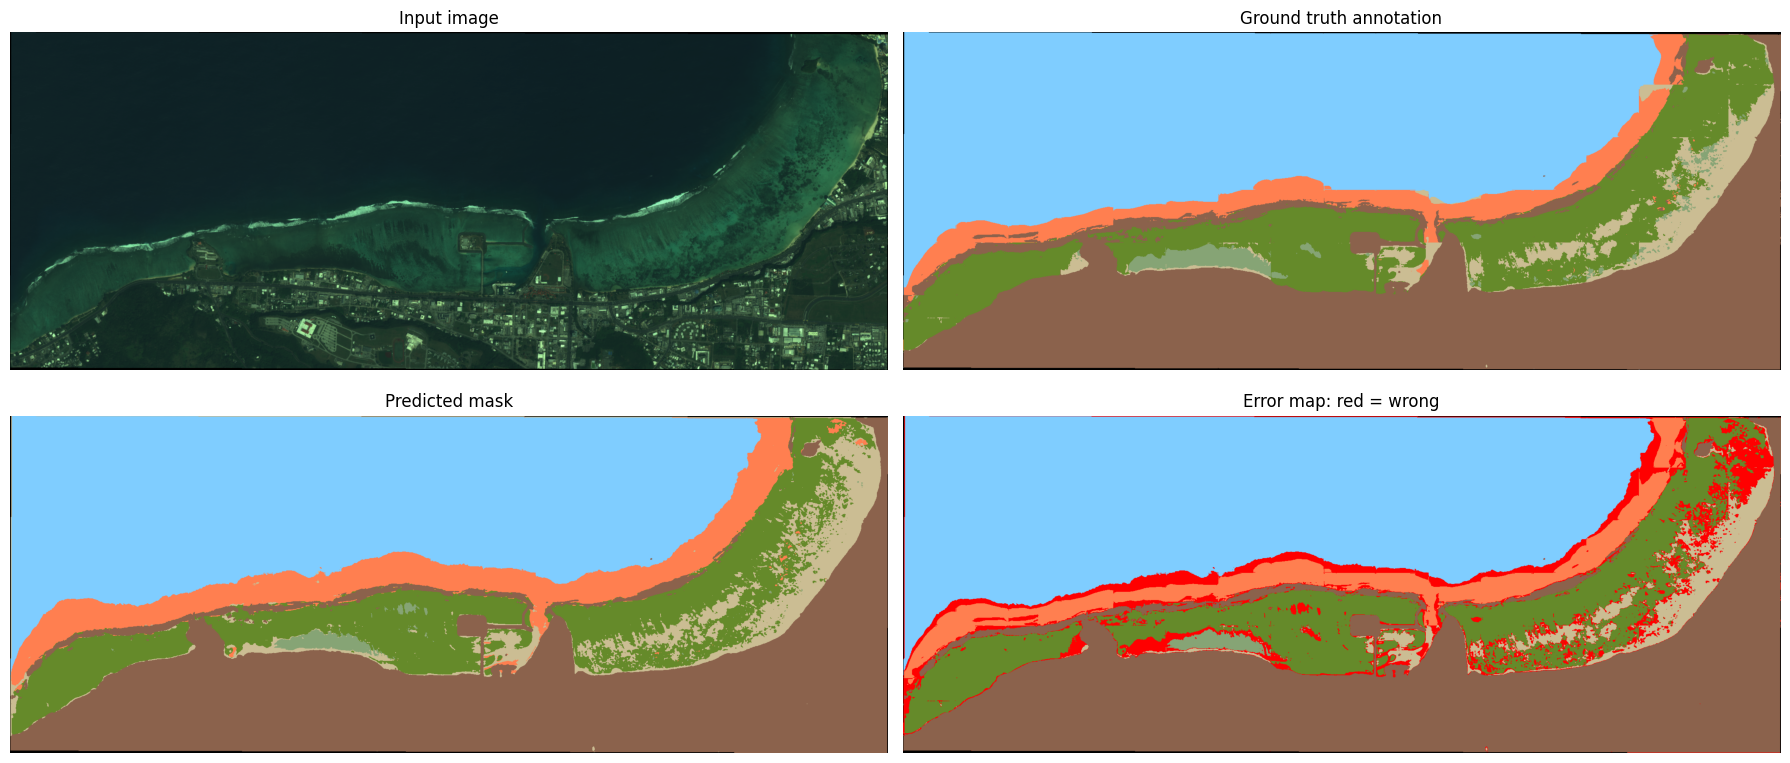

Image: WV10212021_aganaClip
GT unique labels after conversion: [0 1 2 3 4 5 6]
Region                             Agana
Image               WV10212021_aganaClip
Pixel Accuracy                  0.931898
mIoU                             0.73579
IoU_0_Background                0.946705
IoU_1_Seagrass                  0.337581
IoU_2_Coral                     0.648118
IoU_3_Macroalgae                 0.79582
IoU_4_Sand                      0.509057
IoU_5_Land                      0.965303
IoU_6_Ocean                     0.947944
Name: 0, dtype: object


In [ ]:
sample_idx = 0

row = test_results_df.iloc[sample_idx]
region = row["Region"]
base = row["Image"]

if region == "Agana":
    img_path = os.path.join(TEST1_IMG_DIR, base + ".tif")
    gt_path = os.path.join(TEST1_MASK_DIR, base + ".png")
else:
    img_path = os.path.join(TEST3_IMG_DIR, base + ".tif")
    gt_path = os.path.join(TEST3_MASK_DIR, base + ".png")

pred_color_path = os.path.join(COLOR_OUT_DIR, f"{region}_{base}_pred_color.png")
error_path = os.path.join(ERROR_OUT_DIR, f"{region}_{base}_error.png")

# Read image
with rasterio.open(img_path) as src:
    img = src.read().astype(np.float32)

# Visualization RGB
rgb = np.stack([img[4], img[2], img[1]], axis=-1)
rgb = rgb - rgb.min()
rgb = rgb / (rgb.max() + 1e-8)

# Read GT
gt_rgb = np.array(Image.open(gt_path).convert("RGB"))
gt_class = rgb_png_to_class_mask(gt_rgb, class_colors)
gt_recolored = class_mask_to_rgb(gt_class, class_colors).astype(np.uint8)

plt.figure(figsize=(18, 8))

plt.subplot(2, 2, 1)
plt.imshow(rgb)
plt.title("Input image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(gt_rgb)
plt.title("Ground truth annotation")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(Image.open(pred_color_path))
plt.title("Predicted mask")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(Image.open(error_path))
plt.title("Error map: red = wrong")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Image:", base)
print("GT unique labels after conversion:", np.unique(gt_class))
print(row)

In [ ]:
def inspect_rgb_colors(png_path, top_k=20):
    rgb = np.array(Image.open(png_path).convert("RGB"))
    flat = rgb.reshape(-1, 3)

    colors, counts = np.unique(flat, axis=0, return_counts=True)
    order = np.argsort(counts)[::-1]

    print("File:", os.path.basename(png_path))
    print("Shape:", rgb.shape)
    print("Number of unique RGB colors:", len(colors))
    print("\nTop colors:")
    for i in order[:top_k]:
        print(colors[i], counts[i])

    print("\nTraining class colors:")
    for cls_id, cls_name in enumerate(CLASS_NAMES):
        print(cls_id, cls_name, class_colors[cls_id])

inspect_rgb_colors(test1_masks[0])
print("\n" + "="*80 + "\n")
inspect_rgb_colors(test3_masks[0])

File: WV10212021_aganaClip.png
Shape: (822, 2138, 3)
Number of unique RGB colors: 7

Top colors:
[127 205 255] 722939
[139  98  76] 563953
[101 138  42] 267368
[255 127  80] 97945
[203 189 147] 67721
[134 164 117] 21501
[0 0 0] 16009

Training class colors:
0 Background [0 0 0]
1 Seagrass [134 164 117]
2 Coral [255 127  80]
3 Macroalgae [101 138  42]
4 Sand [203 189 147]
5 Land [139  98  76]
6 Ocean [127 205 255]


File: WV3_01132022_MGclip.png
Shape: (1370, 2050, 3)
Number of unique RGB colors: 7

Top colors:
[139  98  76] 1233533
[101 138  42] 361563
[127 205 255] 325944
[0 0 0] 263718
[255 127  80] 254907
[203 189 147] 249290
[134 164 117] 119545

Training class colors:
0 Background [0 0 0]
1 Seagrass [134 164 117]
2 Coral [255 127  80]
3 Macroalgae [101 138  42]
4 Sand [203 189 147]
5 Land [139  98  76]
6 Ocean [127 205 255]


In [ ]:
sample_idx = 0

row = test_results_df.iloc[sample_idx]
region = row["Region"]
base = row["Image"]

pred_color_path = os.path.join(COLOR_OUT_DIR, f"{region}_{base}_pred_color.png")
error_path = os.path.join(ERROR_OUT_DIR, f"{region}_{base}_error.png")

if region == "Agana":
    img_path = os.path.join(TEST1_IMG_DIR, base + ".tif")
    gt_path = os.path.join(TEST1_MASK_DIR, base + ".png")
else:
    img_path = os.path.join(TEST3_IMG_DIR, base + ".tif")
    gt_path = os.path.join(TEST3_MASK_DIR, base + ".png")

with rasterio.open(img_path) as src:
    img = src.read().astype(np.float32)

# RGB-style visualization using selected bands
rgb = np.stack([img[4], img[2], img[1]], axis=-1)
rgb = rgb - rgb.min()
rgb = rgb / (rgb.max() + 1e-8)

gt_rgb = np.array(Image.open(gt_path).convert("RGB"))

plt.figure(figsize=(18, 8))

plt.subplot(2, 2, 1)
plt.imshow(rgb)
plt.title("Input image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(gt_rgb)
plt.title("Ground truth annotation")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(Image.open(pred_color_path))
plt.title("Predicted mask")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(Image.open(error_path))
plt.title("Error map: red = wrong")
plt.axis("off")

plt.tight_layout()
plt.show()

print(row)

In [8]:
!ls -lh "/content/drive/MyDrive/best_benthic_unet.pth"

-rw------- 1 root root 7.5M May 14 18:22 /content/drive/MyDrive/best_benthic_unet.pth


In [9]:
import os, glob, warnings
import numpy as np
import pandas as pd
import rasterio
from rasterio.errors import NotGeoreferencedWarning
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

warnings.filterwarnings("ignore", category=NotGeoreferencedWarning)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

DATA_ROOT = "/content/project4/Project 4 Dataset"

TEST1_IMG_DIR = f"{DATA_ROOT}/test_data/1/images"
TEST1_MASK_DIR = f"{DATA_ROOT}/test_data/1/annotations"

TEST3_IMG_DIR = f"{DATA_ROOT}/test_data/3/images"
TEST3_MASK_DIR = f"{DATA_ROOT}/test_data/3/annotations"

NUM_CLASSES = 7
CLASS_NAMES = [
    "Background",
    "Seagrass",
    "Coral",
    "Macroalgae",
    "Sand",
    "Land",
    "Ocean"
]

BAND_MEAN = np.array([
    333.43406829, 312.73237045, 366.93164551, 276.62686318,
    170.52224063, 256.37608106, 304.45562999, 236.65274939
], dtype=np.float32)

BAND_STD = np.array([
    106.48109747, 127.77042916, 205.53932894, 204.27003298,
    144.62084736, 251.54459058, 359.86817663, 283.61326644
], dtype=np.float32)

class_colors = np.array([
    [0, 0, 0],          # Background
    [134, 164, 117],   # Seagrass
    [255, 127, 80],    # Coral
    [101, 138, 42],    # Macroalgae
    [203, 189, 147],   # Sand
    [139, 98, 76],     # Land
    [127, 205, 255],   # Ocean
], dtype=np.uint8)


class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Dropout2d(dropout)
        )

    def forward(self, x):
        return self.block(x)


class UNetSmall(nn.Module):
    def __init__(self, in_channels=8, num_classes=7, base_channels=32):
        super().__init__()

        self.enc1 = DoubleConv(in_channels, base_channels)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(base_channels, base_channels * 2)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(base_channels * 2, base_channels * 4)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(base_channels * 4, base_channels * 8)

        self.up3 = nn.ConvTranspose2d(base_channels * 8, base_channels * 4, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(base_channels * 8, base_channels * 4)

        self.up2 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(base_channels * 4, base_channels * 2)

        self.up1 = nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(base_channels * 2, base_channels)

        self.out_conv = nn.Conv2d(base_channels, num_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)

        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))

        b = self.bottleneck(self.pool3(e3))

        d3 = self.up3(b)
        if d3.shape[-2:] != e3.shape[-2:]:
            d3 = F.interpolate(d3, size=e3.shape[-2:], mode="bilinear", align_corners=False)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        if d2.shape[-2:] != e2.shape[-2:]:
            d2 = F.interpolate(d2, size=e2.shape[-2:], mode="bilinear", align_corners=False)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        if d1.shape[-2:] != e1.shape[-2:]:
            d1 = F.interpolate(d1, size=e1.shape[-2:], mode="bilinear", align_corners=False)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out_conv(d1)


def rgb_png_to_class_mask(rgb_mask, class_colors):
    rgb_mask = rgb_mask.astype(np.uint8)
    h, w, _ = rgb_mask.shape
    class_mask = np.zeros((h, w), dtype=np.uint8)
    matched = np.zeros((h, w), dtype=bool)

    for cls_id, color in enumerate(class_colors):
        match = np.all(rgb_mask == color.reshape(1, 1, 3), axis=-1)
        class_mask[match] = cls_id
        matched |= match

    if not np.all(matched):
        rgb = rgb_mask.astype(np.int32)
        colors = class_colors.astype(np.int32)
        distances = ((rgb[:, :, None, :] - colors[None, None, :, :]) ** 2).sum(axis=-1)
        nearest = np.argmin(distances, axis=-1).astype(np.uint8)
        class_mask[~matched] = nearest[~matched]

    return class_mask


def class_mask_to_rgb(mask, class_colors):
    return class_colors[mask]


def read_and_normalize_tif(img_path):
    with rasterio.open(img_path) as src:
        img = src.read().astype(np.float32)

    img = np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)
    img = (img - BAND_MEAN[:, None, None]) / (BAND_STD[:, None, None] + 1e-8)

    return img


def sliding_window_predict(model, img, patch_size=256, stride=128, batch_size=16):
    model.eval()

    c, h, w = img.shape
    ps = patch_size

    pad_h = max(0, ps - h)
    pad_w = max(0, ps - w)

    if pad_h > 0 or pad_w > 0:
        img = np.pad(img, ((0, 0), (0, pad_h), (0, pad_w)), mode="reflect")

    _, hp, wp = img.shape

    y_positions = list(range(0, hp - ps + 1, stride))
    x_positions = list(range(0, wp - ps + 1, stride))

    if y_positions[-1] != hp - ps:
        y_positions.append(hp - ps)
    if x_positions[-1] != wp - ps:
        x_positions.append(wp - ps)

    prob_sum = torch.zeros((NUM_CLASSES, hp, wp), dtype=torch.float32, device=device)
    count_sum = torch.zeros((1, hp, wp), dtype=torch.float32, device=device)

    patches = []
    coords = []

    with torch.no_grad():
        for y0 in y_positions:
            for x0 in x_positions:
                patch = img[:, y0:y0 + ps, x0:x0 + ps]
                patches.append(patch)
                coords.append((y0, x0))

                if len(patches) == batch_size:
                    batch = torch.tensor(np.stack(patches), dtype=torch.float32).to(device)
                    logits = model(batch)
                    probs = torch.softmax(logits, dim=1)

                    for i, (yy, xx) in enumerate(coords):
                        prob_sum[:, yy:yy + ps, xx:xx + ps] += probs[i]
                        count_sum[:, yy:yy + ps, xx:xx + ps] += 1.0

                    patches = []
                    coords = []

        if len(patches) > 0:
            batch = torch.tensor(np.stack(patches), dtype=torch.float32).to(device)
            logits = model(batch)
            probs = torch.softmax(logits, dim=1)

            for i, (yy, xx) in enumerate(coords):
                prob_sum[:, yy:yy + ps, xx:xx + ps] += probs[i]
                count_sum[:, yy:yy + ps, xx:xx + ps] += 1.0

    avg_probs = prob_sum / count_sum
    pred = torch.argmax(avg_probs, dim=0).detach().cpu().numpy().astype(np.uint8)

    return pred[:h, :w]


def compute_confusion_matrix(preds, targets, num_classes=7):
    preds = preds.reshape(-1)
    targets = targets.reshape(-1)

    mask = (targets >= 0) & (targets < num_classes)

    hist = np.bincount(
        num_classes * targets[mask].astype(int) + preds[mask].astype(int),
        minlength=num_classes ** 2
    ).reshape(num_classes, num_classes)

    return hist


def metrics_from_confusion(hist):
    correct = np.diag(hist).sum()
    total = hist.sum()
    pixel_acc = correct / (total + 1e-8)

    intersection = np.diag(hist)
    union = hist.sum(axis=1) + hist.sum(axis=0) - intersection

    iou = np.full(NUM_CLASSES, np.nan, dtype=np.float64)
    valid = union > 0
    iou[valid] = intersection[valid] / union[valid]

    miou = np.nanmean(iou)

    return pixel_acc, miou, iou


def make_error_visualization(pred_mask, gt_mask):
    pred_rgb = class_mask_to_rgb(pred_mask, class_colors).astype(np.uint8)
    error_rgb = pred_rgb.copy()

    wrong = pred_mask != gt_mask
    error_rgb[wrong] = np.array([255, 0, 0], dtype=np.uint8)

    return error_rgb


# Load saved model
model = UNetSmall(in_channels=8, num_classes=NUM_CLASSES, base_channels=32).to(device)

checkpoint_path = "/content/drive/MyDrive/best_benthic_unet.pth"
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()

print("Loaded checkpoint:", checkpoint_path)


# Output folders
OUT_DIR = "/content/benthic_results"
MASK_OUT_DIR = f"{OUT_DIR}/predicted_masks"
COLOR_OUT_DIR = f"{OUT_DIR}/colored_predictions"
ERROR_OUT_DIR = f"{OUT_DIR}/error_visualizations"

os.makedirs(MASK_OUT_DIR, exist_ok=True)
os.makedirs(COLOR_OUT_DIR, exist_ok=True)
os.makedirs(ERROR_OUT_DIR, exist_ok=True)


def run_test_folder(region_name, img_dir, mask_dir):
    img_paths = sorted(glob.glob(f"{img_dir}/*.tif"))
    region_rows = []

    for img_path in img_paths:
        base = os.path.splitext(os.path.basename(img_path))[0]
        gt_path = os.path.join(mask_dir, base + ".png")

        print(f"Processing {region_name}: {base}")

        img = read_and_normalize_tif(img_path)

        pred_mask = sliding_window_predict(
            model,
            img,
            patch_size=256,
            stride=128,
            batch_size=16
        )

        pred_id_path = os.path.join(MASK_OUT_DIR, f"{region_name}_{base}_pred_ids.png")
        Image.fromarray(pred_mask).save(pred_id_path)

        pred_rgb = class_mask_to_rgb(pred_mask, class_colors).astype(np.uint8)
        pred_color_path = os.path.join(COLOR_OUT_DIR, f"{region_name}_{base}_pred_color.png")
        Image.fromarray(pred_rgb).save(pred_color_path)

        if os.path.exists(gt_path):
            gt_rgb = np.array(Image.open(gt_path).convert("RGB"))
            gt_mask = rgb_png_to_class_mask(gt_rgb, class_colors)

            hist = compute_confusion_matrix(pred_mask, gt_mask, NUM_CLASSES)
            pixel_acc, miou, per_class_iou = metrics_from_confusion(hist)

            error_rgb = make_error_visualization(pred_mask, gt_mask)
            error_path = os.path.join(ERROR_OUT_DIR, f"{region_name}_{base}_error.png")
            Image.fromarray(error_rgb).save(error_path)

            row = {
                "Region": region_name,
                "Image": base,
                "Pixel Accuracy": pixel_acc,
                "mIoU": miou
            }

            for cls_id, cls_name in enumerate(CLASS_NAMES):
                row[f"IoU_{cls_id}_{cls_name}"] = per_class_iou[cls_id]

            region_rows.append(row)

    return region_rows


test_rows = []
test_rows += run_test_folder("Agana", TEST1_IMG_DIR, TEST1_MASK_DIR)
test_rows += run_test_folder("ManellGeus", TEST3_IMG_DIR, TEST3_MASK_DIR)

test_results_df = pd.DataFrame(test_rows)

metrics_csv_path = f"{OUT_DIR}/test_metrics.csv"
test_results_df.to_csv(metrics_csv_path, index=False)

print("\nSaved metrics:", metrics_csv_path)
print("\nOverall test results:")
print("Mean Pixel Accuracy:", test_results_df["Pixel Accuracy"].mean() * 100)
print("Mean mIoU:", test_results_df["mIoU"].mean() * 100)

print("\nBy region:")
print(test_results_df.groupby("Region")[["Pixel Accuracy", "mIoU"]].mean() * 100)

test_results_df

Device: cuda
GPU: NVIDIA A100-SXM4-40GB
Loaded checkpoint: /content/drive/MyDrive/best_benthic_unet.pth
Processing Agana: WV10212021_aganaClip
Processing Agana: WV3_01112021_aganaclip
Processing Agana: WV3_01182021_aganaClip
Processing Agana: WV3_07302023_AganaClip
Processing Agana: WV_01132022_AganaClip
Processing Agana: WV_01152013_AganaClip
Processing Agana: WV_02052014_aganaclip
Processing Agana: WV_02052023_AganaClip
Processing Agana: WV_02292020_AganaClip
Processing Agana: WV_03082022_composite_aganaclip
Processing Agana: WV_05122018_aganaclip
Processing Agana: WV_07272015_AganaClip
Processing Agana: WV_10202017_aganaClip
Processing Agana: WV_11102016_Aganaclip
Processing Agana: WV_12152010_AganaClip
Processing ManellGeus: WV3_01132022_MGclip
Processing ManellGeus: WV3_02202022_MGclip
Processing ManellGeus: WV3_12302014_MGclip
Processing ManellGeus: WV3_20220113_Composite_8bands_Manell_AOI_XSM_updated
Processing ManellGeus: WV_MG_01052024_composite_clip
Processing ManellGeus: WV_

,Region,Image,Pixel Accuracy,mIoU,IoU_0_Background,IoU_1_Seagrass,IoU_2_Coral,IoU_3_Macroalgae,IoU_4_Sand,IoU_5_Land,IoU_6_Ocean
0,Agana,WV10212021_aganaClip,0.931898,0.735790,0.946705,0.337581,0.648118,0.795820,0.509057,0.965303,0.947944
1,Agana,WV3_01112021_aganaclip,0.407035,0.338078,0.927481,0.122417,0.000297,0.277527,0.082042,0.956782,0.000000
2,Agana,WV3_01182021_aganaClip,0.355405,0.279335,0.841124,0.023443,0.000000,0.067621,0.135437,0.887717,0.000000
3,Agana,WV3_07302023_AganaClip,0.857763,0.612933,0.849042,0.201446,0.646058,0.447428,0.268933,0.948260,0.929365
4,Agana,WV_01132022_AganaClip,0.949592,0.798246,0.946681,0.460365,0.773375,0.812630,0.634892,0.985097,0.974680
5,Agana,WV_01152013_AganaClip,0.933475,0.778721,0.928931,0.503234,0.622142,0.744188,0.715495,0.985958,0.951097
6,Agana,WV_02052014_aganaclip,0.941680,0.815217,0.953435,0.568476,0.670081,0.764440,0.822246,0.988910,0.938932
7,Agana,WV_02052023_AganaClip,0.950763,0.825563,0.946390,0.546139,0.802788,0.804169,0.718768,0.991934,0.968752
8,Agana,WV_02292020_AganaClip,0.947220,0.819128,0.948734,0.543191,0.729594,0.786596,0.778004,0.990998,0.956777
9,Agana,WV_03082022_composite_aganaclip,0.870914,0.658962,0.884191,0.237266,0.638710,0.323724,0.592906,0.986249,0.949688


In [10]:
!cd /content && zip -r benthic_results.zip benthic_results
!cp /content/benthic_results.zip "/content/drive/MyDrive/benthic_results.zip"

print("Final results ZIP saved to:")
print("/content/drive/MyDrive/benthic_results.zip")

  adding: benthic_results/ (stored 0%)
  adding: benthic_results/colored_predictions/ (stored 0%)
  adding: benthic_results/colored_predictions/ManellGeus_WV3_02202022_MGclip_pred_color.png (deflated 3%)
  adding: benthic_results/colored_predictions/Agana_WV_02052023_AganaClip_pred_color.png (deflated 4%)
  adding: benthic_results/colored_predictions/ManellGeus_WV_MG_01052024_composite_clip_pred_color.png (deflated 2%)
  adding: benthic_results/colored_predictions/Agana_WV_01132022_AganaClip_pred_color.png (deflated 6%)
  adding: benthic_results/colored_predictions/ManellGeus_WV3_12302014_MGclip_pred_color.png (deflated 4%)
  adding: benthic_results/colored_predictions/Agana_WV_12152010_AganaClip_pred_color.png (deflated 5%)
  adding: benthic_results/colored_predictions/ManellGeus_WV_MG_02142024_composite_clip_pred_color.png (deflated 6%)
  adding: benthic_results/colored_predictions/Agana_WV_02292020_AganaClip_pred_color.png (deflated 6%)
  adding: benthic_results/colored_predictions/

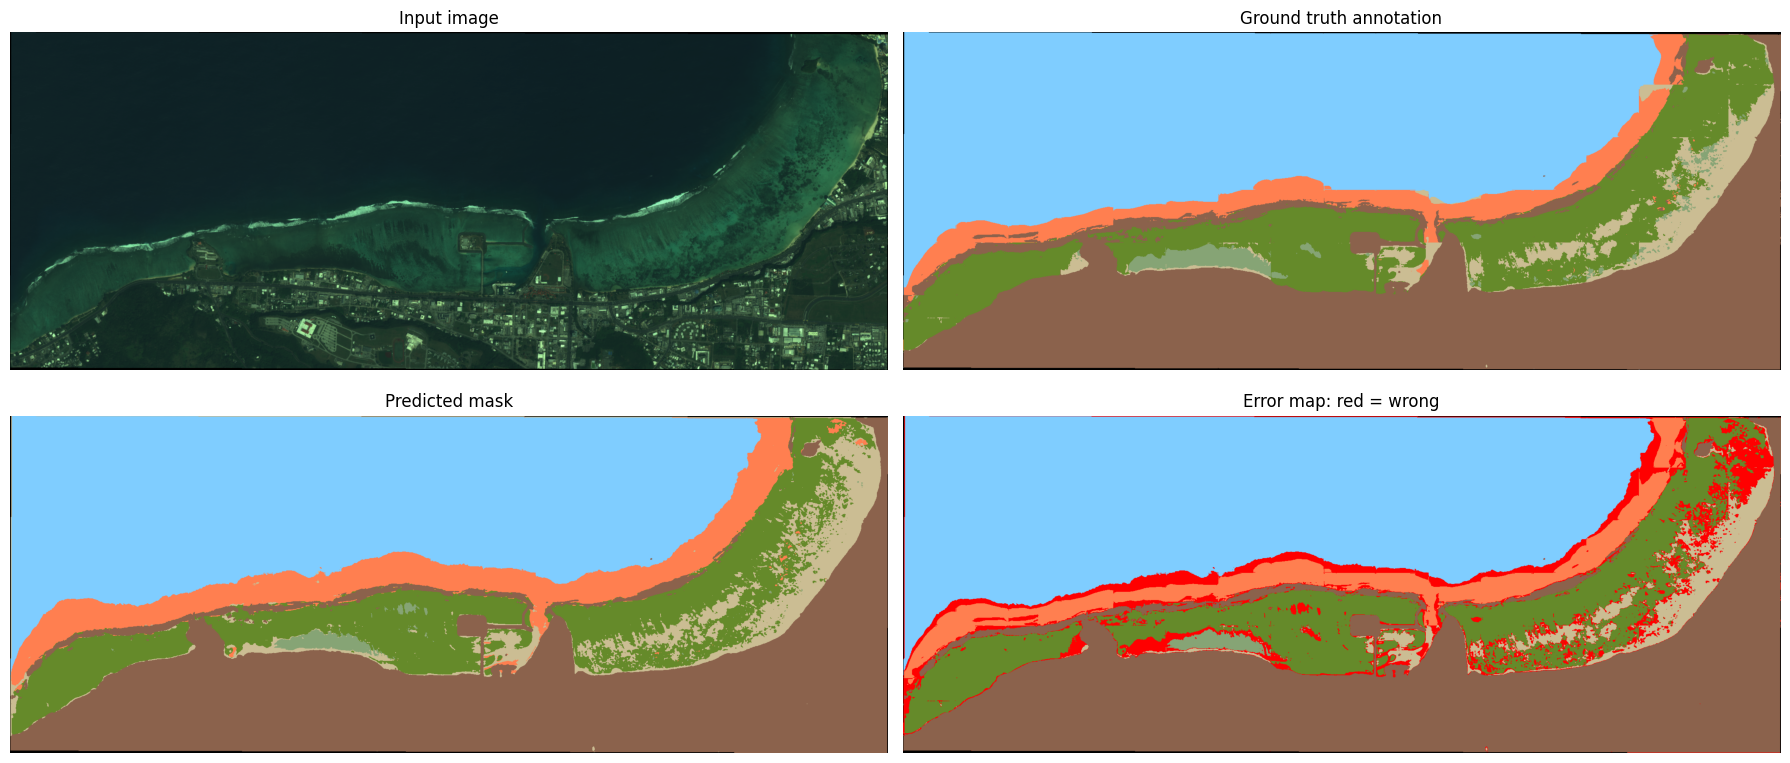

Saved report figure: /content/benthic_results/sample_prediction_error_figure.png
Region                             Agana
Image               WV10212021_aganaClip
Pixel Accuracy                  0.931898
mIoU                             0.73579
IoU_0_Background                0.946705
IoU_1_Seagrass                  0.337581
IoU_2_Coral                     0.648118
IoU_3_Macroalgae                 0.79582
IoU_4_Sand                      0.509057
IoU_5_Land                      0.965303
IoU_6_Ocean                     0.947944
Name: 0, dtype: object


In [11]:
sample_idx = 0

row = test_results_df.iloc[sample_idx]
region = row["Region"]
base = row["Image"]

if region == "Agana":
    img_path = os.path.join(TEST1_IMG_DIR, base + ".tif")
    gt_path = os.path.join(TEST1_MASK_DIR, base + ".png")
else:
    img_path = os.path.join(TEST3_IMG_DIR, base + ".tif")
    gt_path = os.path.join(TEST3_MASK_DIR, base + ".png")

pred_color_path = os.path.join(COLOR_OUT_DIR, f"{region}_{base}_pred_color.png")
error_path = os.path.join(ERROR_OUT_DIR, f"{region}_{base}_error.png")

with rasterio.open(img_path) as src:
    img = src.read().astype(np.float32)

rgb = np.stack([img[4], img[2], img[1]], axis=-1)
rgb = rgb - rgb.min()
rgb = rgb / (rgb.max() + 1e-8)

gt_rgb = np.array(Image.open(gt_path).convert("RGB"))

plt.figure(figsize=(18, 8))

plt.subplot(2, 2, 1)
plt.imshow(rgb)
plt.title("Input image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(gt_rgb)
plt.title("Ground truth annotation")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(Image.open(pred_color_path))
plt.title("Predicted mask")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(Image.open(error_path))
plt.title("Error map: red = wrong")
plt.axis("off")

plt.tight_layout()

fig_path = "/content/benthic_results/sample_prediction_error_figure.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved report figure:", fig_path)
print(row)

In [12]:
!cd /content && zip -r benthic_results.zip benthic_results
!cp /content/benthic_results.zip "/content/drive/MyDrive/benthic_results.zip"

print("Final results ZIP saved to:")
print("/content/drive/MyDrive/benthic_results.zip")

updating: benthic_results/ (stored 0%)
updating: benthic_results/colored_predictions/ (stored 0%)
updating: benthic_results/colored_predictions/ManellGeus_WV3_02202022_MGclip_pred_color.png (deflated 3%)
updating: benthic_results/colored_predictions/Agana_WV_02052023_AganaClip_pred_color.png (deflated 4%)
updating: benthic_results/colored_predictions/ManellGeus_WV_MG_01052024_composite_clip_pred_color.png (deflated 2%)
updating: benthic_results/colored_predictions/Agana_WV_01132022_AganaClip_pred_color.png (deflated 6%)
updating: benthic_results/colored_predictions/ManellGeus_WV3_12302014_MGclip_pred_color.png (deflated 4%)
updating: benthic_results/colored_predictions/Agana_WV_12152010_AganaClip_pred_color.png (deflated 5%)
updating: benthic_results/colored_predictions/ManellGeus_WV_MG_02142024_composite_clip_pred_color.png (deflated 6%)
updating: benthic_results/colored_predictions/Agana_WV_02292020_AganaClip_pred_color.png (deflated 6%)
updating: benthic_results/colored_predictions/

In [13]:
!unzip -l "/content/drive/MyDrive/benthic_results.zip" | head -50

Archive:  /content/drive/MyDrive/benthic_results.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
        0  2026-05-21 15:12   benthic_results/
        0  2026-05-21 15:11   benthic_results/colored_predictions/
    98412  2026-05-21 15:11   benthic_results/colored_predictions/ManellGeus_WV3_02202022_MGclip_pred_color.png
    55074  2026-05-21 15:11   benthic_results/colored_predictions/Agana_WV_02052023_AganaClip_pred_color.png
   171009  2026-05-21 15:11   benthic_results/colored_predictions/ManellGeus_WV_MG_01052024_composite_clip_pred_color.png
    56866  2026-05-21 15:11   benthic_results/colored_predictions/Agana_WV_01132022_AganaClip_pred_color.png
    98836  2026-05-21 15:11   benthic_results/colored_predictions/ManellGeus_WV3_12302014_MGclip_pred_color.png
    60614  2026-05-21 15:11   benthic_results/colored_predictions/Agana_WV_12152010_AganaClip_pred_color.png
    72701  2026-05-21 15:11   benthic_results/colored_predictions/ManellGeus_WV_MG_0214202